# Simple Deep Learning On Male Data - ASVspoof2019 Dataset:

In [1]:
import sys
sys.path.append('../')
import scipy.io as sio
import mat73
import pandas as pd
import torch
import numpy as np
import torch.optim as optim
import torch.nn
import sklearn
import sklearn.metrics
import matplotlib.pyplot as plt
from alive_progress import alive_bar
from  utils.my_classes import dataset 
from torch.utils.data import DataLoader
import utils.DNN_functions as DNN_functions
import scipy
import random
import utils.AMSloss
seed = 190  # You can choose any integer value as the seed
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
# Set seed for Python's random module
random.seed(seed)
# Set seed for NumPy
np.random.seed(seed)
# Set seed for PyTorch (CPU and GPU, if available)
if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
# Set deterministic flags for PyTorch (if available)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
#To get my GPU device - GTX 4070 :)
seed = 190  # You can choose any integer value as the seed
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu');

if torch.cuda.is_available():
    print(torch.cuda.device_count())
    print(torch.cuda.device(0))
    print(torch.cuda.get_device_name(0))
    print(device)

1
NVIDIA GeForce RTX 4070
cuda


In [3]:
from ASV_utils.data_loading import *


data_path_female = "Data/pmf_both/not_normalize/female/"


embedded_groups_1_1,embedded_groups_1_2,embedded_groups_1_3,chosen_labels_1_1_is_spoofed,chosen_labels_2_1_is_spoofed,chosen_labels_3_1_is_spoofed,chosen_labels_numeric_1_1,chosen_labels_numeric_2_1,chosen_labels_numeric_3_1,chosen_labels_1_1_attack_logical,chosen_labels_2_1_attack_logical,chosen_labels_3_1_attack_logical,chosen_labels_1_1_name,chosen_labels_2_1_name,chosen_labels_3_1_name,chosen_labels_1_1_speaker_id,chosen_labels_2_1_speaker_id,chosen_labels_3_1_speaker_id,chosen_labels_1_1_sex,chosen_labels_2_1_sex,chosen_labels_3_1_sex  = load_data_female(data_path_female)



In [4]:
#order by this example:
#filter-gammatone-channel-1-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Hellinger-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Intersection-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Jensen-Shannon-[d_(p,p_s)-d(p,p_h)

# get the real channel by the order of the features

import utils.my_functions as my_functions
columns_names,max_name_length = my_functions.get_columns_names_feature_importance(substruct=True)
true_channels_indexes = np.array(my_functions.get_real_channel(np.linspace(start=1, stop=len(columns_names), num=len(columns_names)),len(columns_names)))
true_channels_indexes = true_channels_indexes - 1
true_channels_indexes = true_channels_indexes.astype(int)
columns_names = np.array(columns_names)
embedded_groups_1_1 = embedded_groups_1_1[:,true_channels_indexes]
embedded_groups_1_2 = embedded_groups_1_2[:,true_channels_indexes]
embedded_groups_1_3 = embedded_groups_1_3[:,true_channels_indexes]



In [5]:
# order by metric type and then by channel number and then by gammatone and gammatone_inv, example:
#filter-gammatone-channel-1-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-2-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-3-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-4-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-5-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-6-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-7-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-8-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-9-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-10-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-1-distance-Correlation-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-2-distance-Correlation-[d_(p,p_s)-d(p,p_h)]
import re


your_list = columns_names[true_channels_indexes]
index_mapping ={}

# Define the custom sorting order for distance metrics
distance_metrics = [
    'Chi-square',
    'Correlation',
    'Hellinger',
    'Intersection',
    'Jensen-Shannon',
    'Kullback-Leibler Divergence',
    'Modified Kolmogorov-Smirnov',
    'Symmetrised Kullback-Leibler'
]

def custom_sort_key(item):
    # Use regex to extract filter type, channel number, and distance metric
    match = re.search(r'filter-(gammatone|gammtone_inv)-channel-(\d+)-distance-(.+?)-\[d_', item)
    if match:
        filter_type = match.group(1)  # 'gammatone' or 'gammtone_inv'
        channel = int(match.group(2))
        distance_metric = match.group(3)
        
        # Prioritize 'gammatone' before 'gammtone_inv'
        filter_priority = 0 if filter_type == 'gammatone' else 1

        # Sort by filter type, then by distance metric, and finally by channel
        return (filter_priority, distance_metrics.index(distance_metric), channel)

    else:
        # If the regex doesn't match, push the item to the end
        return (999, 999, 999)

# Sort the list based on the custom order
sorted_list = sorted(your_list, key=custom_sort_key)

for new_index, item in enumerate(sorted_list):
    old_index = np.where(columns_names[true_channels_indexes] == item)[0][0]
    index_mapping[old_index] = new_index
    
embedded_groups_1_1 = embedded_groups_1_1[:,list(index_mapping.keys())]
embedded_groups_1_2 = embedded_groups_1_2[:,list(index_mapping.keys())]
embedded_groups_1_3 = embedded_groups_1_3[:,list(index_mapping.keys())]

In [6]:
sorted_list

['filter-gammatone-channel-1-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-2-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-3-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-4-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-5-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-6-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-7-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-8-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-9-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-10-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-1-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-2-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-3-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-4-distance-Correlation-[d_(p,p_s)

In [7]:
train_dataset = dataset(data = embedded_groups_1_1 , is_spoofed = chosen_labels_1_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_1_1,
                        attack_logical = chosen_labels_1_1_attack_logical, name = chosen_labels_1_1_name , speaker_id = chosen_labels_1_1_speaker_id,sex = chosen_labels_1_1_sex, data_transform = None , labels_transform = None);

validation_dataset = dataset(data = embedded_groups_1_2 , is_spoofed = chosen_labels_2_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_2_1,
                        attack_logical = chosen_labels_2_1_attack_logical, name = chosen_labels_2_1_name , speaker_id = chosen_labels_2_1_speaker_id, sex = chosen_labels_2_1_sex ,data_transform = None , labels_transform = None);


test_dataset = dataset(data = embedded_groups_1_3 , is_spoofed = chosen_labels_3_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_3_1,
                        attack_logical = chosen_labels_3_1_attack_logical, name = chosen_labels_3_1_name , speaker_id = chosen_labels_3_1_speaker_id, sex = chosen_labels_3_1_sex ,data_transform = None , labels_transform = None);

In [8]:
# normalize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(with_mean = True, with_std = True)
scaler.fit(train_dataset.data)
mean_features = scaler.mean_
std_features = scaler.scale_
train_dataset.data = scaler.transform(train_dataset.data)
validation_dataset.data = scaler.transform(validation_dataset.data)
test_dataset.data = scaler.transform(test_dataset.data)

In [9]:
import imblearn.over_sampling as over_sampling
#sm = over_sampling.ADASYN(sampling_strategy='minority', random_state=seed,n_neighbors=5)
sm = over_sampling.SVMSMOTE(sampling_strategy='minority', random_state=seed,k_neighbors=5)
train_dataset.data, train_dataset.is_spoofed = sm.fit_resample(X = train_dataset.data, y = train_dataset.is_spoofed) # just on the train set

In [10]:
print(f"|| train dataset length - {len(train_dataset)} ||");
print(f"|| train dataset - len_is_spoofed ? \nlength - \n{train_dataset.len_is_spoofed()} ||");
print(f"|| validation dataset length - {len(validation_dataset)} ||");
print(f"|| validation dataset - len_is_spoofed ? \nlength - \n{validation_dataset.len_is_spoofed()} ||");
print(f"|| test dataset length - {len(test_dataset)} ||");
print(f"|| test dataset - len_is_spoofed ? \nlength - \n{test_dataset.len_is_spoofed()} ||");

|| train dataset length - 26784 ||
|| train dataset - len_is_spoofed ? 
length - 
0    13392
1    13392
Name: count, dtype: int64 ||
|| validation dataset length - 16584 ||
|| validation dataset - len_is_spoofed ? 
length - 
1    14904
0     1680
Name: count, dtype: int64 ||
|| test dataset length - 49298 ||
|| test dataset - len_is_spoofed ? 
length - 
1    44226
0     5072
Name: count, dtype: int64 ||


In [11]:
train_dataset.set_labels_format('is_spoofed')
validation_dataset.set_labels_format('is_spoofed')
test_dataset.set_labels_format('is_spoofed')

In [12]:
batch_size = 32

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True);
validation_dataloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True);
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True);

print(f"|| train dataloader length - {len(train_dataloader)} ||");
print(f"|| validation dataloader length - {len(validation_dataloader)} ||");
print(f"|| test dataloader length - {len(test_dataloader)} ||");

|| train dataloader length - 837 ||
|| validation dataloader length - 519 ||
|| test dataloader length - 1541 ||


## DNN

In [13]:

import torch.nn as nn
class SubChannelNetwork(nn.Module):
    def __init__(self, input_channel_size, output_channel_size):
        super(SubChannelNetwork, self).__init__()
        self.input_layer = nn.Linear(input_channel_size, output_channel_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.2)
        self.BN_4 = nn.BatchNorm1d(output_channel_size) 
   
    def forward(self, x):
        res = x
        x = self.input_layer(x)
        x = self.BN_4(x) 
        x = self.sigmoid(x)
        x = self.dropout(x)
        x = x + res
        return x

In [14]:
import torch
import torch.nn as nn
from utils.AMSloss import AdMSoftmaxLoss
from utils.OCSoftmaxloss import OCSoftmax


class DNN(nn.Module):
    def __init__(self, input_channel_size, num_subnetworks, output_channel_size, final_output_size, r_real , r_fake,alpha):
        super(DNN, self).__init__()
        self.SubChannelNetwork = nn.ModuleList([
            SubChannelNetwork(input_channel_size, output_channel_size) for _ in range(num_subnetworks)
        ])
        self.fc_between_subnet = nn.Linear(num_subnetworks * output_channel_size,40)
        self.BN = nn.BatchNorm1d(40)
        self.fc = nn.Linear(40, final_output_size)
        self.sigmoid = nn.Sigmoid()
        self.droupout = nn.Dropout(p=0.2)
        self.r_real = r_real
        self.r_fake = r_fake
        self.alpha = alpha
        self.loss = OCSoftmax(feat_dim = final_output_size, r_real = self.r_real, r_fake = self.r_fake, alpha = self.alpha)
        self.optimizer = None
        self.scheduler = None
        self.fc1 = nn.Linear(160, num_subnetworks * output_channel_size)
        self.BN1 = nn.BatchNorm1d(num_subnetworks * output_channel_size)
        self.sigmoid1 = nn.Sigmoid()
        self.dropout1 = nn.Dropout(p=0.2)
        
        
    def forward(self, x):
        # subnetwork_outputs = [self.SubChannelNetwork[idx](x[:, idx*input_channel_size:(idx+1)*input_channel_size].to(device)) for idx in range(len(self.SubChannelNetwork))]
        # combined_output = torch.cat(subnetwork_outputs, dim=1)
        combined_output = self.fc1(x)
        combined_output = self.BN1(combined_output)
        combined_output = self.sigmoid1(combined_output)
        combined_output = self.dropout1(combined_output)
        x = self.fc_between_subnet(combined_output)    
        x = self.BN(x)
        x = self.sigmoid(x)
        x = self.droupout(x)
        output = self.fc(x)
        return output 
    
    @staticmethod
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)


r_real = 0.5 
r_fake = 0.1
alpha = 20
# Example usage
num_SubChannelNetwork = 16
input_channel_size = 10
output_channel_size = 10
final_output_size = 16*3
model = []
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size,r_real = r_real , r_fake = r_fake,alpha = alpha)
model = model.to(device)
print(model)

n = DNN.count_parameters(model)
print("Number of parameters: %s" % n)



DNN(
  (SubChannelNetwork): ModuleList(
    (0-15): 16 x SubChannelNetwork(
      (input_layer): Linear(in_features=10, out_features=10, bias=True)
      (sigmoid): Sigmoid()
      (dropout): Dropout(p=0.2, inplace=False)
      (BN_4): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (fc_between_subnet): Linear(in_features=160, out_features=40, bias=True)
  (BN): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Linear(in_features=40, out_features=48, bias=True)
  (sigmoid): Sigmoid()
  (droupout): Dropout(p=0.2, inplace=False)
  (loss): OCSoftmax(
    (softplus): Softplus(beta=1, threshold=20)
  )
  (fc1): Linear(in_features=160, out_features=160, bias=True)
  (BN1): BatchNorm1d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (sigmoid1): Sigmoid()
  (dropout1): Dropout(p=0.2, inplace=False)
)
Number of parameters: 36696


In [15]:
import utils.DNN_functions
model = []

model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size,r_real = r_real , r_fake = r_fake,alpha = alpha)
model = model.to(device)


num_epoch = 100

learning_rate = 0.0001
weight_decay = 0.0001


model.optimizer = torch.optim.SGD(model.parameters(),
                                lr=learning_rate,
                                weight_decay=weight_decay);


model.scheduler =  optim.lr_scheduler.StepLR(model.optimizer, step_size=num_epoch, gamma=0.1);

checkpoint_path = "Female_best_OCS.pkl"

training_type = '2_neorun_end_OCS'

model,train_losses,validation_losses,train_acc_percentage,validation_acc_percentage,f1_score_validation,validation_total_eer,train_total_err  = utils.DNN_functions.train_model_new(training_type,model,train_dataloader,validation_dataloader ,num_epoch,checkpoint_path=checkpoint_path,patience = None)


c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\torch\onnx\_internal\_beartype.py:35: UserWarning: unhashable type: 'list'
  warnings.warn(f"{e}")


on 1: 
      Train Balanced Accuracy:  68.59%
on 1: Train EER:  31.42%
on 1: 
      Validation 1 ,Validation Loss 2.67370 , Validation Balanced Accuracy: 89.64%
on 1: Validation EER:  10.37%
on 1: Validation f1 Score: 89.63%
on 1: 
on 1: 
on 2: 
      Train Balanced Accuracy:  93.57%
on 2: Train EER:  6.44%
on 2: 
      Validation 2 ,Validation Loss 0.61611 , Validation Balanced Accuracy: 99.32%
on 2: Validation EER:  0.71%
on 2: Validation f1 Score: 99.29%
on 2: 
on 2: 
on 3: 
      Train Balanced Accuracy:  98.69%
on 3: Train EER:  1.31%
on 3: 
      Validation 3 ,Validation Loss 0.27677 , Validation Balanced Accuracy: 99.82%
on 3: Validation EER:  0.19%
on 3: Validation f1 Score: 99.81%
on 3: 
on 3: 
on 4: 
      Train Balanced Accuracy:  99.28%
on 4: Train EER:  0.72%
on 4: 
      Validation 4 ,Validation Loss 0.26094 , Validation Balanced Accuracy: 99.91%
on 4: Validation EER:  0.12%
on 4: Validation f1 Score: 99.89%
on 4: 
on 4: 
on 5: 
      Train Balanced Accuracy:  99.46%
on 5

on 48: c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:653: RuntimeWarning: divide by zero encountered in divide
         slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:656: RuntimeWarning: invalid value encountered in multiply
         y_new = slope*(x_new - x_lo)[:, None] + y_lo


on 49: 
       Train Balanced Accuracy:  100.00%
on 49: Train EER:  0.01%
on 49: 
       Validation 49 ,Validation Loss 0.03573 , Validation Balanced Accuracy: 100.00%
on 49: Validation EER:  0.01%
on 49: Validation f1 Score: 99.99%
on 49: EarlyStopping counter: 2 out of 100
on 49: 
on 49: 
on 50: 
       Train Balanced Accuracy:  100.00%
on 50: Train EER:  0.01%
on 50: 
       Validation 50 ,Validation Loss 0.02477 , Validation Balanced Accuracy: 100.00%
on 50: Validation EER:  0.01%
on 50: Validation f1 Score: 99.99%
on 50: 
on 50: 
on 51: 
       Train Balanced Accuracy:  100.00%
on 51: Train EER:  0.01%
on 51: 
       Validation 51 ,Validation Loss 0.02937 , Validation Balanced Accuracy: 50.00%
on 51: Validation EER:  0.00%
on 51: Validation f1 Score: 10.13%
on 51: EarlyStopping counter: 1 out of 100
on 51: 
on 51: 


on 51: c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:653: RuntimeWarning: divide by zero encountered in divide
         slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:656: RuntimeWarning: invalid value encountered in multiply
         y_new = slope*(x_new - x_lo)[:, None] + y_lo


...

on 99: 
       Train Balanced Accuracy:  50.00%
on 99: Train EER:  0.00%
on 99: 
       Validation 99 ,Validation Loss 0.01765 , Validation Balanced Accuracy: 50.00%
on 99: Validation EER:  0.00%
on 99: Validation f1 Score: 10.13%
on 99: EarlyStopping counter: 17 out of 100
on 99: 
on 99: 


on 99: c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:653: RuntimeWarning: divide by zero encountered in divide
         slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:656: RuntimeWarning: invalid value encountered in multiply
         y_new = slope*(x_new - x_lo)[:, None] + y_lo
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:653: RuntimeWarning: divide by zero encountered in divide
         slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:656: RuntimeWarning: invalid value encountered in multiply
         y_new = slope*(x_new - x_lo)[:, None] + y_lo


on 100: 
        Train Balanced Accuracy:  50.00%
on 100: Train EER:  0.00%
on 100: 
        Validation 100 ,Validation Loss 0.01454 , Validation Balanced Accuracy: 50.00%
on 100: Validation EER:  0.00%
on 100: Validation f1 Score: 10.13%
on 100: 
on 100: 


on 100: c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:653: RuntimeWarning: divide by zero encountered in divide
          slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:656: RuntimeWarning: invalid value encountered in multiply
          y_new = slope*(x_new - x_lo)[:, None] + y_lo
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:653: RuntimeWarning: divide by zero encountered in divide
          slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:656: RuntimeWarning: invalid value encountered in multiply
          y_new = slope*(x_new - x_lo)[:, None] + y_lo


|████████████████████████████████████████| 100/100 [100%] in 10:52.9 (0.00/s) 


In [16]:
import pickle
file_path = 'Female_best_model_10_17.pkl'

# Open the file in binary write mode
with open(file_path, 'wb') as f:
    # Serialize the object and write it to the file
    pickle.dump(model, f)

c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\utils\DNN_functions.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


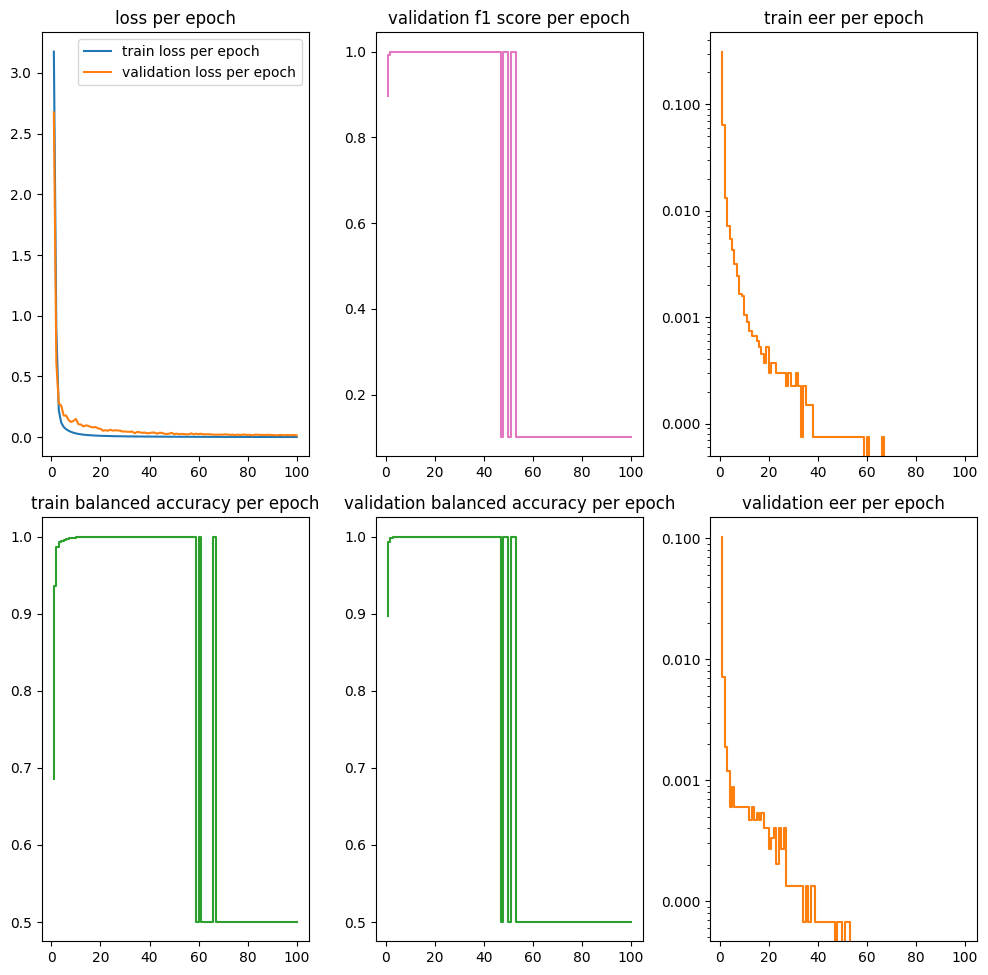

In [17]:
import matplotlib.pyplot as plt
DNN_functions.plot_loss_accuracy(num_epoch,train_losses,validation_losses,train_acc_percentage,validation_acc_percentage,f1_score_validation,validation_total_eer,train_total_err)

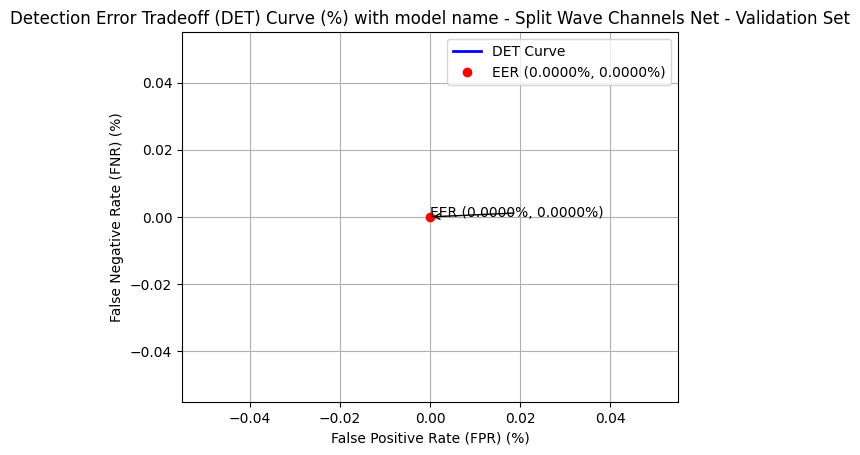

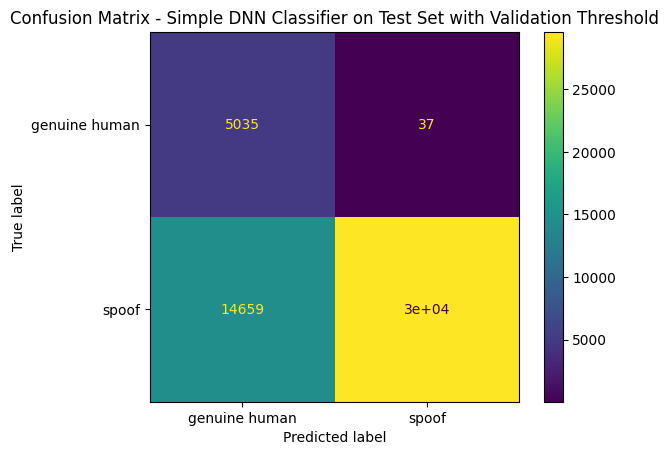

	Test Balanced Accuracy: (0.83062%) 	F1 Score: 0.70189
	Test EER: 0.0 	Threshold: -0.5790263414382935


In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import det_curve
import torch.nn.functional as F 

with torch.no_grad():
    model = model.to(device)
    validation_output = model(torch.Tensor(validation_dataset.data).to(device)).cpu()
    loss , validation_score = model.loss(torch.Tensor(validation_output).to(device),torch.LongTensor(validation_dataset.is_spoofed).to(device))
    validation_score = -1*validation_score
    validation_norm_output = F.normalize(validation_output)
    
validation_score_total = validation_score.cpu().numpy().copy()

validation_total_labels = validation_dataset.is_spoofed.copy()

eer_1,eer_2,eer,val_thresh = my_functions.compute_eer_2(validation_total_labels,validation_score_total) # compute equal error rate

fpr, fnr, _ = det_curve(validation_total_labels, validation_score_total) # compute false positive rate and false negative rate

my_functions.DETCurve(fpr = fpr, fnr = fnr, eer_fpr = eer_1,eer_fnr = eer_1, model_name = "Split Wave Channels Net - Validation Set",plot_type="step") # plot DET curve

with torch.no_grad():
    model = model.to(device)
    test_output = model(torch.Tensor(test_dataset.data).to(device))
    loss , test_score = model.loss(torch.Tensor(test_output).to(device),torch.LongTensor(test_dataset.is_spoofed).to(device))
    test_score = -1*test_score
    test_norm_output = F.normalize(test_output)

test_score_total = test_score.cpu().numpy().copy()

test_total_labels = test_dataset.is_spoofed.copy()

prediction = np.array([1 if total_prob_element > val_thresh else 0 for total_prob_element in test_score_total]) # prediction for specific threshold

valid_thr_prediction_dnn = prediction.copy()

cm = sklearn.metrics.confusion_matrix(test_total_labels, valid_thr_prediction_dnn) # confusion matrix
cm = np.round(cm,2)

# print confusion matrix - logistic regression
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=["genuine human","spoof"])
disp.plot()
plt.title('Confusion Matrix - Simple DNN Classifier on Test Set with Validation Threshold')
plt.show()

    
balanced_acc = sklearn.metrics.balanced_accuracy_score(test_total_labels,valid_thr_prediction_dnn) # balanced accuracy per batch

f1_score =sklearn.metrics.f1_score(test_total_labels, valid_thr_prediction_dnn, average='micro') # f1 score  
   
print(f"\tTest Balanced Accuracy: ({balanced_acc:.5f}%) \tF1 Score: {f1_score:.5f}")
print(f"\tTest EER: {eer} \tThreshold: {val_thresh}")


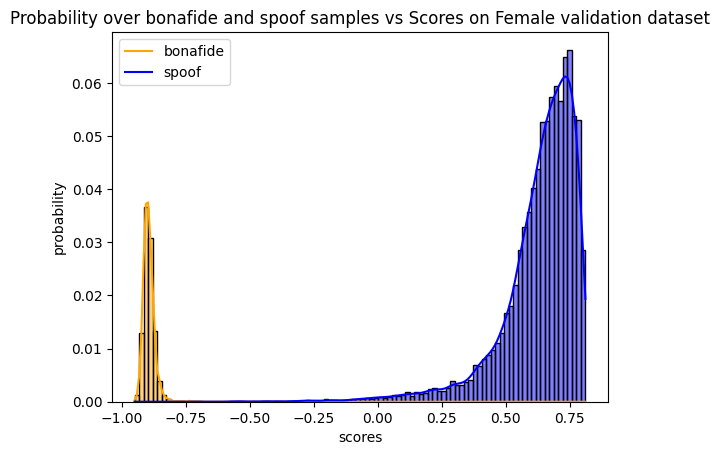

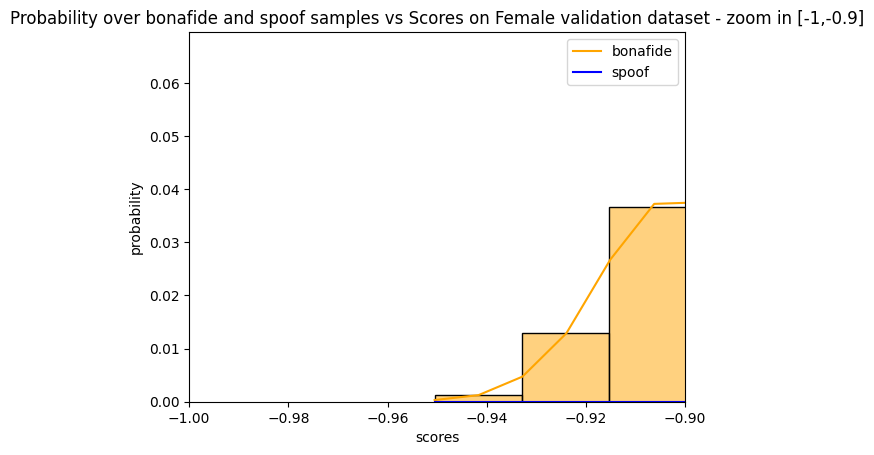

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

bonafide_scores = validation_score[validation_dataset.is_spoofed == 0].flatten()
spoof_scores = validation_score[validation_dataset.is_spoofed == 1].flatten()
bonafide_scores = bonafide_scores.cpu().numpy()
spoof_scores = spoof_scores.cpu().numpy()

num_bins = 100

plt.figure()
sns.histplot([spoof_scores, bonafide_scores], kde=True, stat='probability', bins=num_bins, palette=['blue', 'orange'], linewidth=1)# Add labels and title
plt.legend(['bonafide','spoof'])
plt.xlabel('scores')
plt.ylabel('probability')
plt.title(f"Probability over bonafide and spoof samples vs Scores on Female validation dataset")
# Add legend
# Show the plot
plt.show()

plt.figure()
sns.histplot([spoof_scores, bonafide_scores], kde=True, stat='probability', bins=num_bins, palette=['blue', 'orange'], linewidth=1)# Add labels and title
plt.legend(['bonafide','spoof'])
plt.xlim(-1,-0.9)
plt.xlabel('scores')
plt.ylabel('probability')
plt.title(f"Probability over bonafide and spoof samples vs Scores on Female validation dataset - zoom in [-1,-0.9]")
# Add legend
# Show the plot
plt.show()

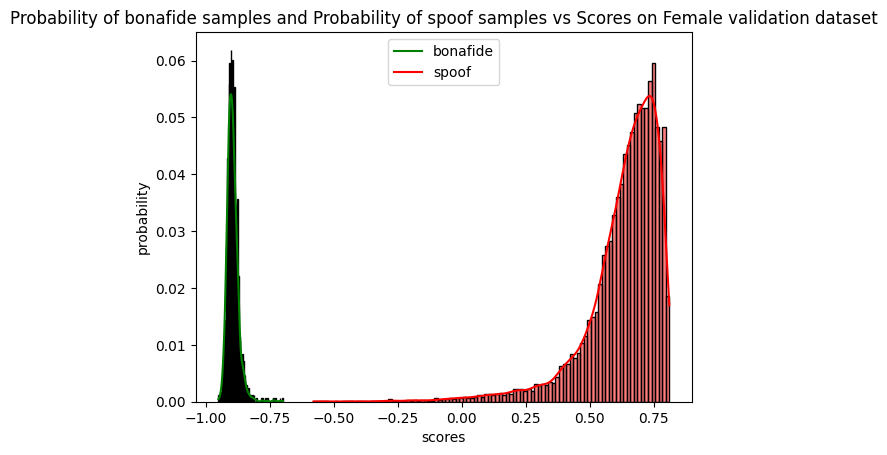

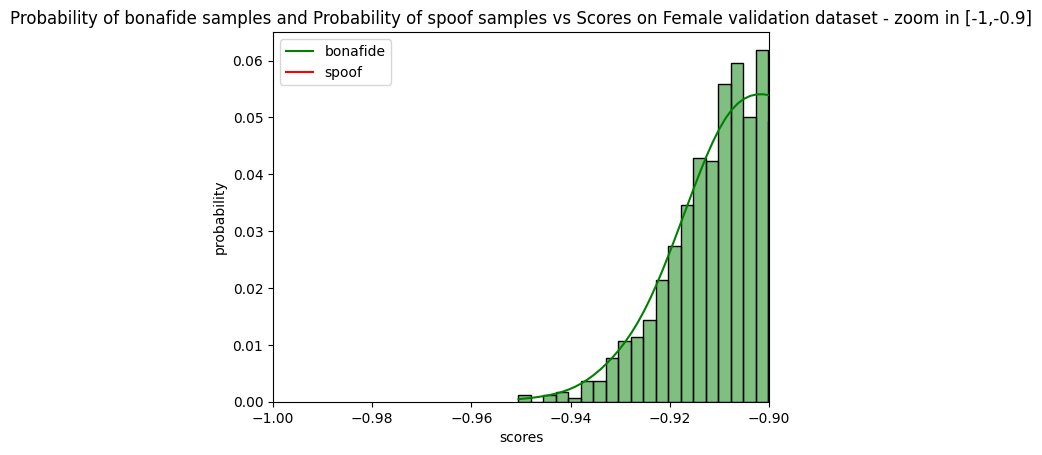

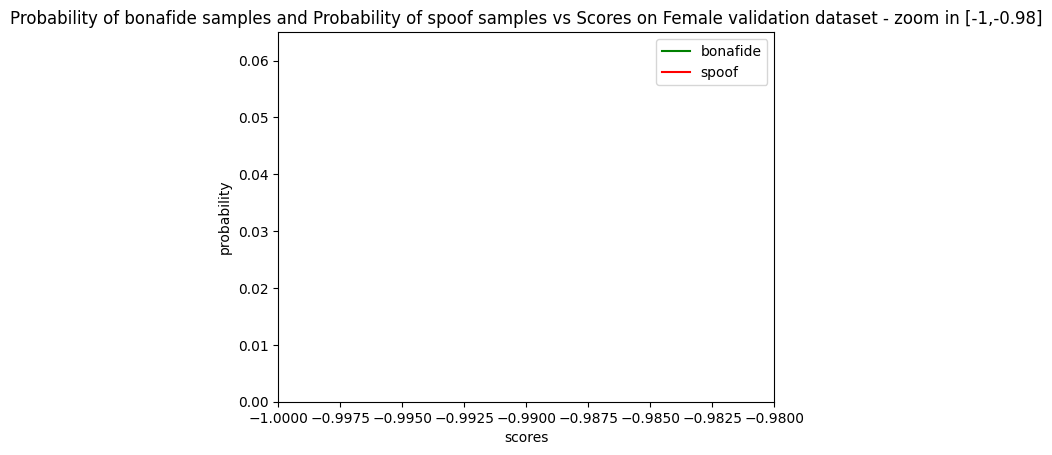

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

bonafide_scores = validation_score[validation_dataset.is_spoofed == 0].flatten()
spoof_scores = validation_score[validation_dataset.is_spoofed == 1].flatten()
bonafide_scores = bonafide_scores.cpu().numpy()
spoof_scores = spoof_scores.cpu().numpy()
num_bins = 100

plt.figure()
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=num_bins, color='green', linewidth=1)# Add labels and title
sns.histplot(spoof_scores, kde=True, stat='probability', bins=num_bins, color='red', linewidth=1)# Add labels and title
plt.legend(['bonafide','spoof'])
plt.xlabel('scores')
plt.ylabel('probability')
plt.title(f"Probability of bonafide samples and Probability of spoof samples vs Scores on Female validation dataset")
# Add legend
# Show the plot
plt.show()

plt.figure()
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=num_bins, color='green', linewidth=1)# Add labels and title
sns.histplot(spoof_scores, kde=True, stat='probability', bins=num_bins, color='red', linewidth=1)# Add labels and title
plt.legend(['bonafide','spoof'])
plt.xlim(-1,-0.9)
plt.xlabel('scores')
plt.ylabel('probability')
plt.title(f"Probability of bonafide samples and Probability of spoof samples vs Scores on Female validation dataset - zoom in [-1,-0.9]")
# Add legend
# Show the plot
plt.show()

plt.figure()
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=num_bins, color='green', linewidth=1)# Add labels and title
sns.histplot(spoof_scores, kde=True, stat='probability', bins=num_bins, color='red', linewidth=1)# Add labels and title
plt.legend(['bonafide','spoof'])
plt.xlim(-1,-0.98)
plt.xlabel('scores')
plt.ylabel('probability')
plt.title(f"Probability of bonafide samples and Probability of spoof samples vs Scores on Female validation dataset - zoom in [-1,-0.98]")
# Add legend
# Show the plot
plt.show()

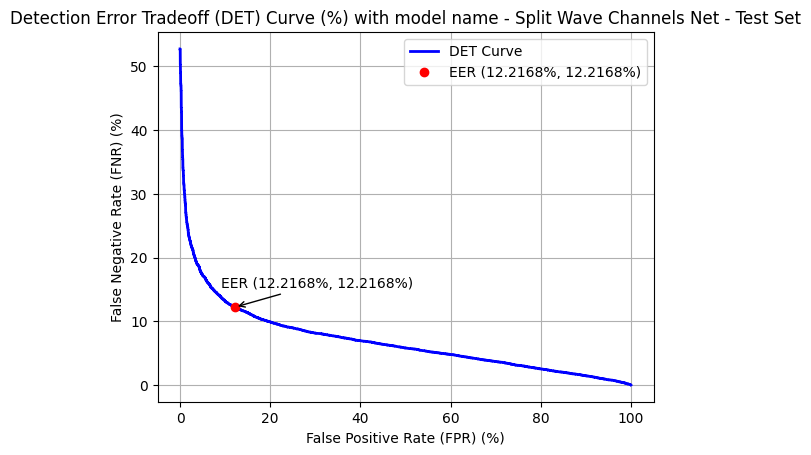

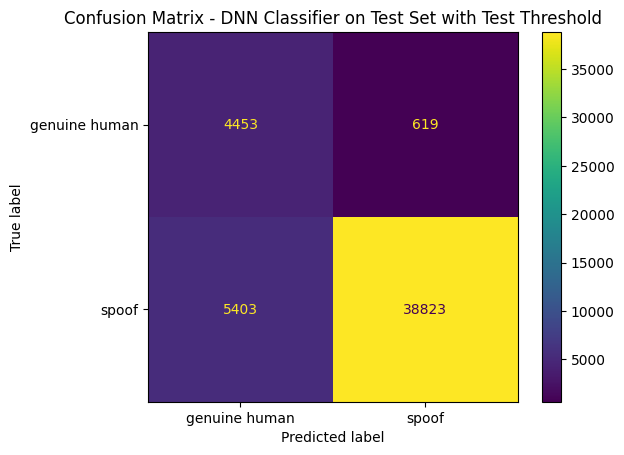

	Test Balanced Accuracy: (0.87789%) 	F1 Score: 0.87784
	Test EER: (0.12216795550165252%) 	Test Threshold: -0.8583449288998809


In [21]:
total_labels = torch.Tensor(test_dataset.is_spoofed.iloc[:]).cpu().numpy().copy()

with torch.no_grad():
    model = model.to(device)
    test_output = model(torch.Tensor(test_dataset.data).to(device))
    loss , test_score = model.loss(torch.Tensor(test_output).to(device),torch.LongTensor(total_labels).to(device))
    test_score = -1*test_score
    test_norm_output = F.normalize(test_output)
    
test_score_total = test_score.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(total_labels,test_score_total) # compute equal error rate

fpr, fnr, _ = det_curve(total_labels, test_score_total) # compute false positive rate and false negative rate

my_functions.DETCurve(fpr = fpr, fnr = fnr, eer_fpr = eer,eer_fnr = eer, model_name = "Split Wave Channels Net - Test Set",plot_type="step") # plot DET curve
    
prediction = np.array([1 if total_prob_element > test_thresh else 0 for total_prob_element in test_score_total]) # prediction for specific threshold

test_thr_prediction_dnn = prediction.copy()

cm = sklearn.metrics.confusion_matrix(total_labels, test_thr_prediction_dnn) # confusion matrix
cm = np.round(cm,2)

# print confusion matrix - logistic regression
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=["genuine human","spoof"])
disp.plot()
plt.title('Confusion Matrix - DNN Classifier on Test Set with Test Threshold')
plt.show()

    
balanced_acc= sklearn.metrics.balanced_accuracy_score(total_labels,test_thr_prediction_dnn) # balanced accuracy per batch

f1_score =sklearn.metrics.f1_score(total_labels, test_thr_prediction_dnn, average='micro') # f1 score  
   
print(f"\tTest Balanced Accuracy: ({balanced_acc:.5f}%) \tF1 Score: {f1_score:.5f}")
print(f"\tTest EER: ({eer}%) \tTest Threshold: {test_thresh}")

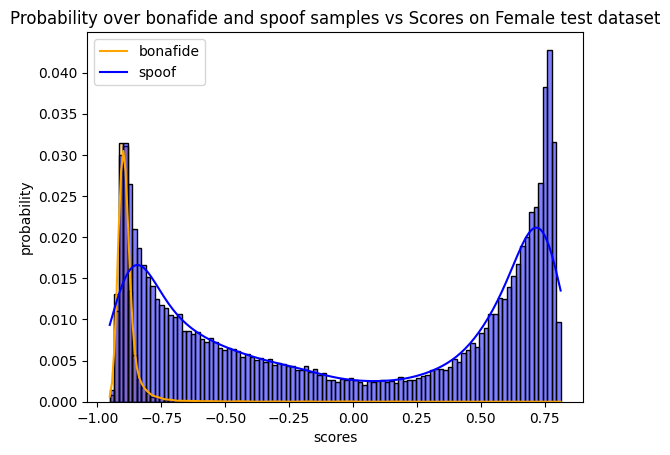

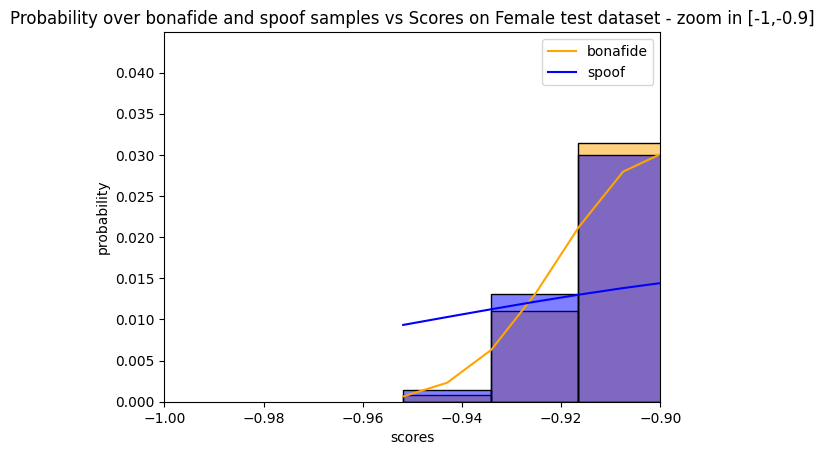

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

bonafide_scores = test_score[test_dataset.is_spoofed == 0].flatten()
spoof_scores = test_score[test_dataset.is_spoofed == 1].flatten()

bonafide_scores = bonafide_scores.cpu().numpy()
spoof_scores = spoof_scores.cpu().numpy()

num_bins = 100

plt.figure()
sns.histplot([spoof_scores, bonafide_scores], kde=True, stat='probability', bins=num_bins, palette=['blue', 'orange'], linewidth=1)# Add labels and title
plt.legend(['bonafide','spoof'])
plt.xlabel('scores')
plt.ylabel('probability')
plt.title(f"Probability over bonafide and spoof samples vs Scores on Female test dataset")
# Add legend
# Show the plot
plt.show()

plt.figure()
sns.histplot([spoof_scores, bonafide_scores], kde=True, stat='probability', bins=num_bins, palette=['blue', 'orange'], linewidth=1)# Add labels and title
plt.legend(['bonafide','spoof'])
plt.xlim(-1,-0.9)
plt.xlabel('scores')
plt.ylabel('probability')
plt.title(f"Probability over bonafide and spoof samples vs Scores on Female test dataset - zoom in [-1,-0.9]")
# Add legend
# Show the plot
plt.show()

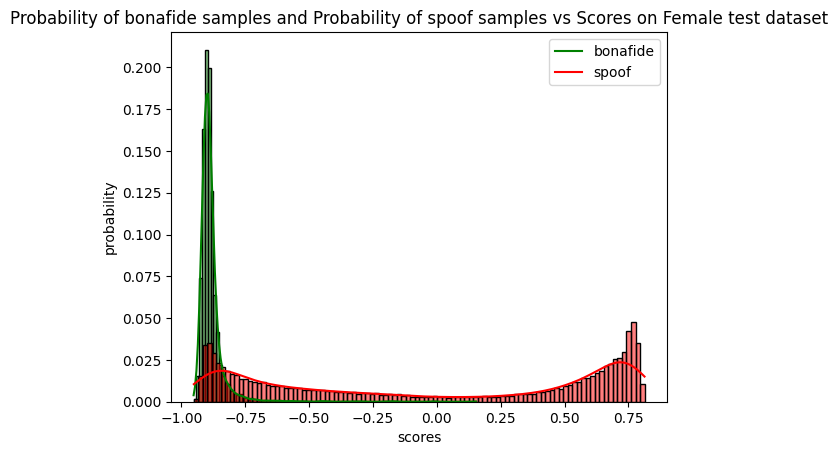

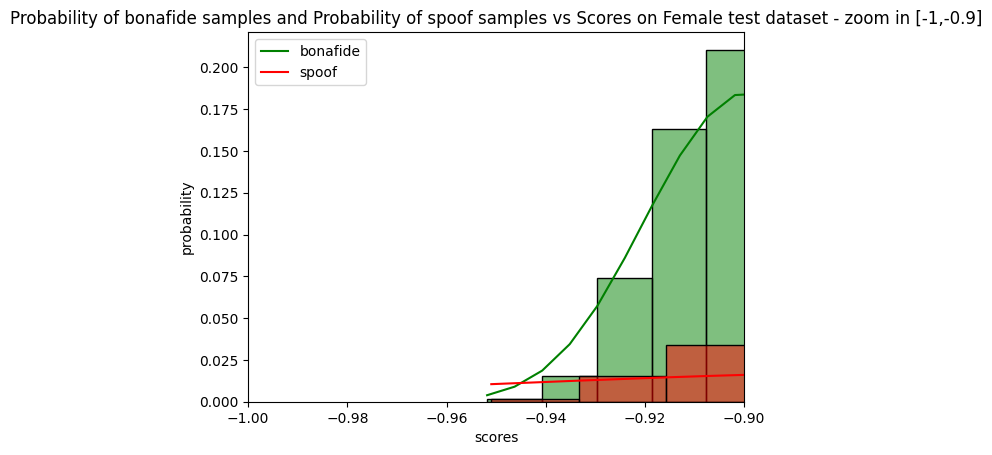

In [23]:
bonafide_scores = test_score[test_dataset.is_spoofed == 0].flatten()
spoof_scores = test_score[test_dataset.is_spoofed == 1].flatten()

bonafide_scores = bonafide_scores.cpu().numpy()
spoof_scores = spoof_scores.cpu().numpy()

num_bins = 100

plt.figure()
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=num_bins, color='green', linewidth=1)# Add labels and title
sns.histplot(spoof_scores, kde=True, stat='probability', bins=num_bins, color='red', linewidth=1)# Add labels and title
plt.legend(['bonafide','spoof'])
plt.xlabel('scores')
plt.ylabel('probability')
plt.title(f"Probability of bonafide samples and Probability of spoof samples vs Scores on Female test dataset")
# Add legend
# Show the plot
plt.show()

plt.figure()
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=num_bins, color='green', linewidth=1)# Add labels and title
sns.histplot(spoof_scores, kde=True, stat='probability', bins=num_bins, color='red', linewidth=1)# Add labels and title
plt.legend(['bonafide','spoof'])
plt.xlim(-1,-0.9)
plt.xlabel('scores')
plt.ylabel('probability')
plt.title(f"Probability of bonafide samples and Probability of spoof samples vs Scores on Female test dataset - zoom in [-1,-0.9]")
# Add legend
# Show the plot
plt.show()


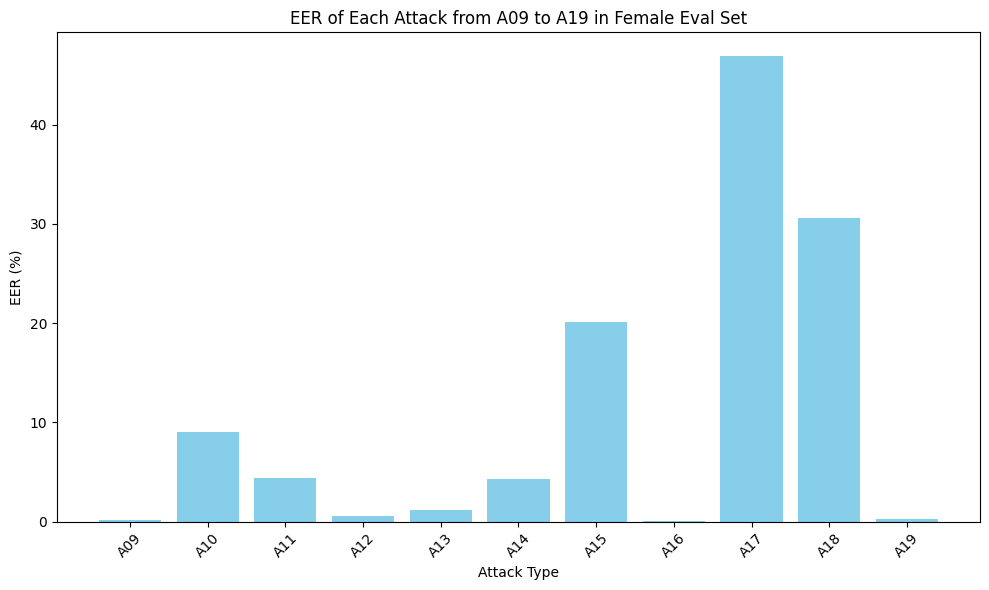

In [24]:
def test_attacks_cm(cm_score,attack_type,cm_label):
    
    eer_cm_lst = []
    for attack_idx in range(9,20):
       
        # Extract bona fide (real human) and spoof scores from the CM scores
        
        indexes_bona = np.where(cm_label == 0)
        indexes_attacks = np.where(attack_type == 'A%02d' % attack_idx)
        
        cm_scores_temp = np.concatenate((cm_score[indexes_bona], cm_score[indexes_attacks]))
        
        cm_labels_temp = np.concatenate((cm_label[indexes_bona], cm_label[indexes_attacks]))
        
        eer_cm = my_functions.compute_eer(cm_labels_temp, cm_scores_temp)
        eer_cm_lst.append(eer_cm)
    
    return eer_cm_lst

eer_cm_lst = test_attacks_cm(test_score.cpu(),test_dataset.attack_logical.values,test_dataset.is_spoofed.values)

eer_values = [100*eer[0] for eer in eer_cm_lst]

# Attack labels from A09 to A20
attack_labels = [f'A{str(i).zfill(2)}' for i in range(9, 20)]

# Create bar plot
plt.figure(figsize=(10, 6))
plt.bar(attack_labels, eer_values, color='skyblue')
plt.xlabel('Attack Type')
plt.ylabel('EER (%)')
plt.title('EER of Each Attack from A09 to A19 in Female Eval Set')
plt.xticks(rotation=45)
plt.tight_layout()

# Display plot
plt.show()

In [25]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report,accuracy_score
from sklearn.metrics import balanced_accuracy_score


pred_proba_list = [test_score_total]
y_pred = [test_thr_prediction_dnn]

test_total_labels = [test_dataset.is_spoofed.iloc[:].astype('uint8')]

eer_list = []
acc_list = []
balanced_acc_list = []
auc_list = []
f1_list = [] 
for i in range(0,len(pred_proba_list)): # calculate the EER for each model
     eer , _ = my_functions.compute_eer(test_total_labels[i],pred_proba_list[i])
     eer_list.append(eer)
     acc_list.append(accuracy_score(test_total_labels[i], y_pred[i]))
     balanced_acc_list.append(balanced_accuracy_score(test_total_labels[i], y_pred[i]))
     auc_list.append(roc_auc_score(test_total_labels[i],pred_proba_list[i]))
     f1_list.append(sklearn.metrics.f1_score(test_total_labels[i], y_pred[i]))
  
     
y_pred_with_valid_thr = [valid_thr_prediction_dnn] 

validation_pos_pred_proba_list = [validation_score_total]    

valid_total_labels = [validation_dataset.is_spoofed.iloc[:].astype('uint8')]


eer_list_on_validaion = []
acc_list_with_valid_thr = []
balanced_acc_list_with_valid_thr = []
f1_list_with_valid_thr = []
for i in range(0,len(validation_pos_pred_proba_list)): # calculate the EER for each model
     acc_list_with_valid_thr.append(accuracy_score(test_total_labels[i], y_pred_with_valid_thr[i]))
     balanced_acc_list_with_valid_thr.append(balanced_accuracy_score(test_total_labels[i], y_pred_with_valid_thr[i]))
     f1_list_with_valid_thr.append(sklearn.metrics.f1_score(test_total_labels[i], y_pred_with_valid_thr[i]))
     eer_val , _ = my_functions.compute_eer(valid_total_labels[i],validation_pos_pred_proba_list[i])
     eer_list_on_validaion.append(eer_val)

c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:653: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:656: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


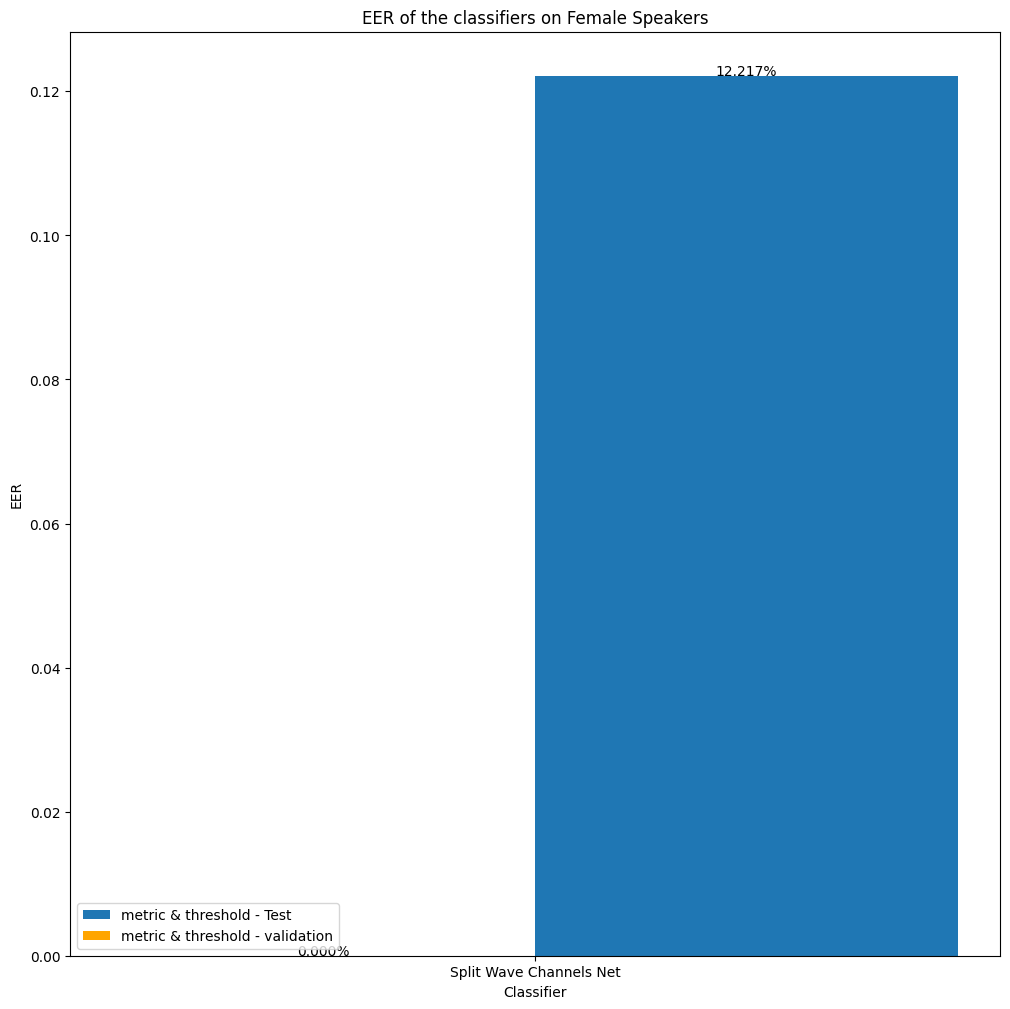

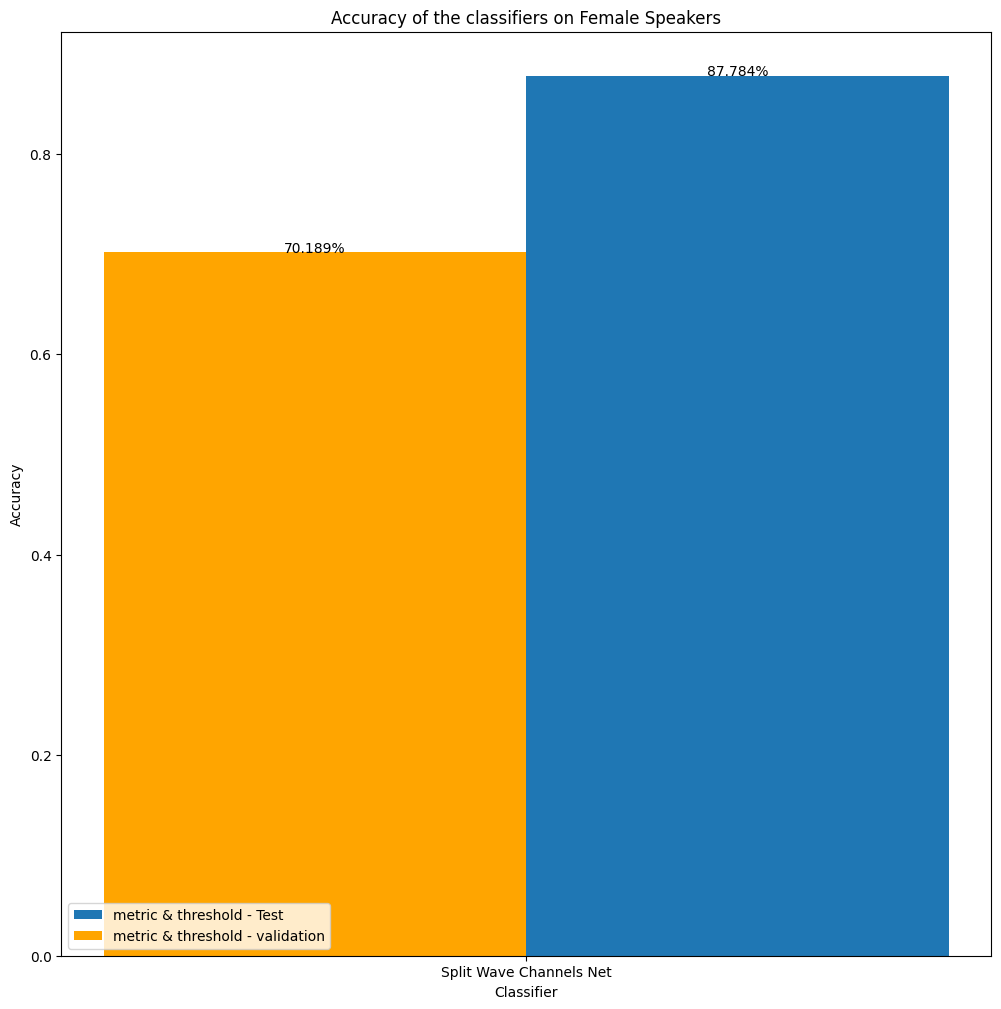

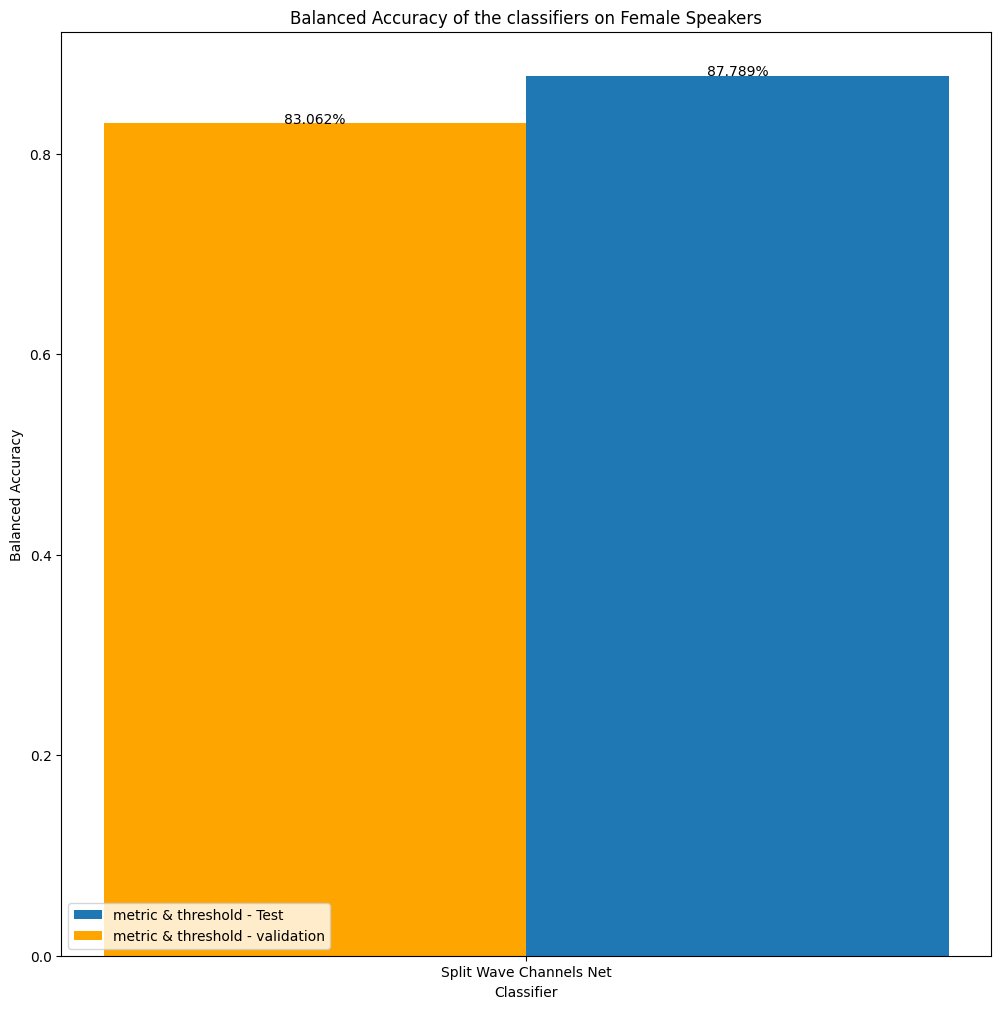

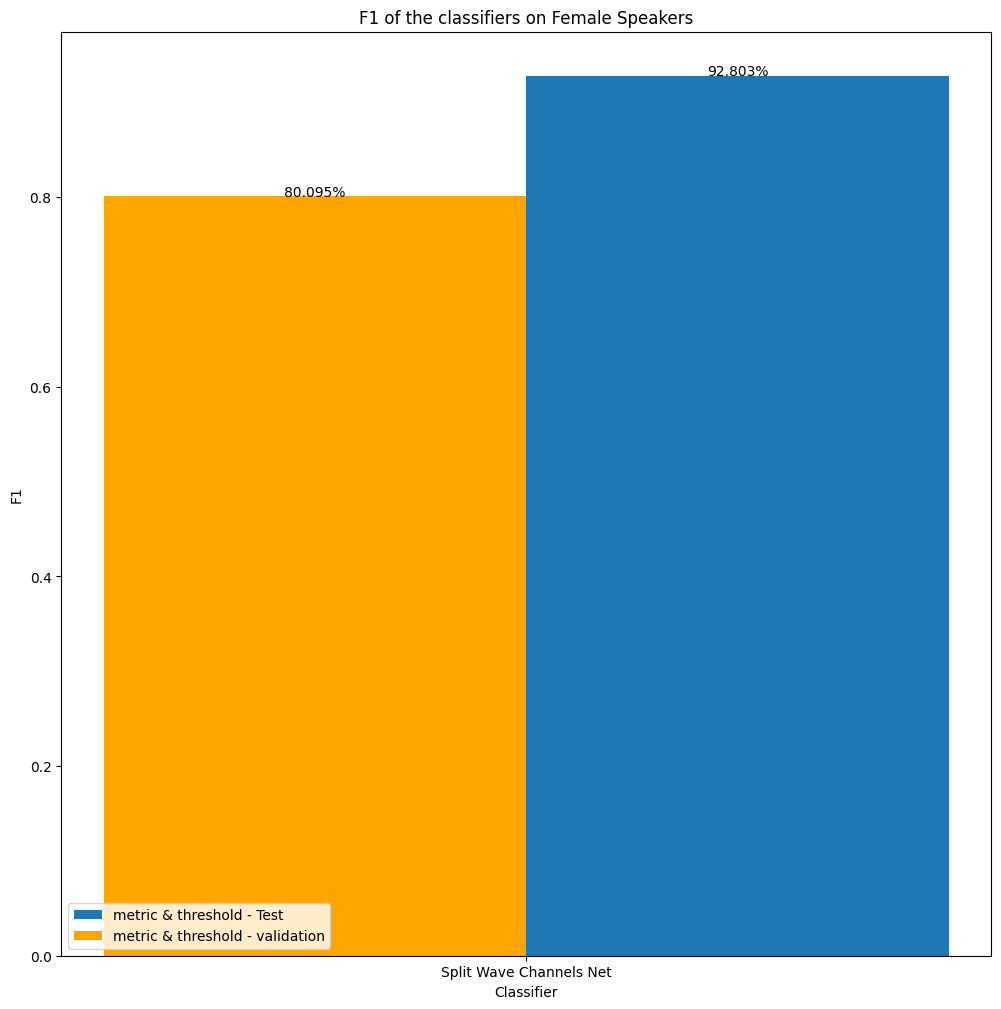

<Figure size 1200x1200 with 0 Axes>

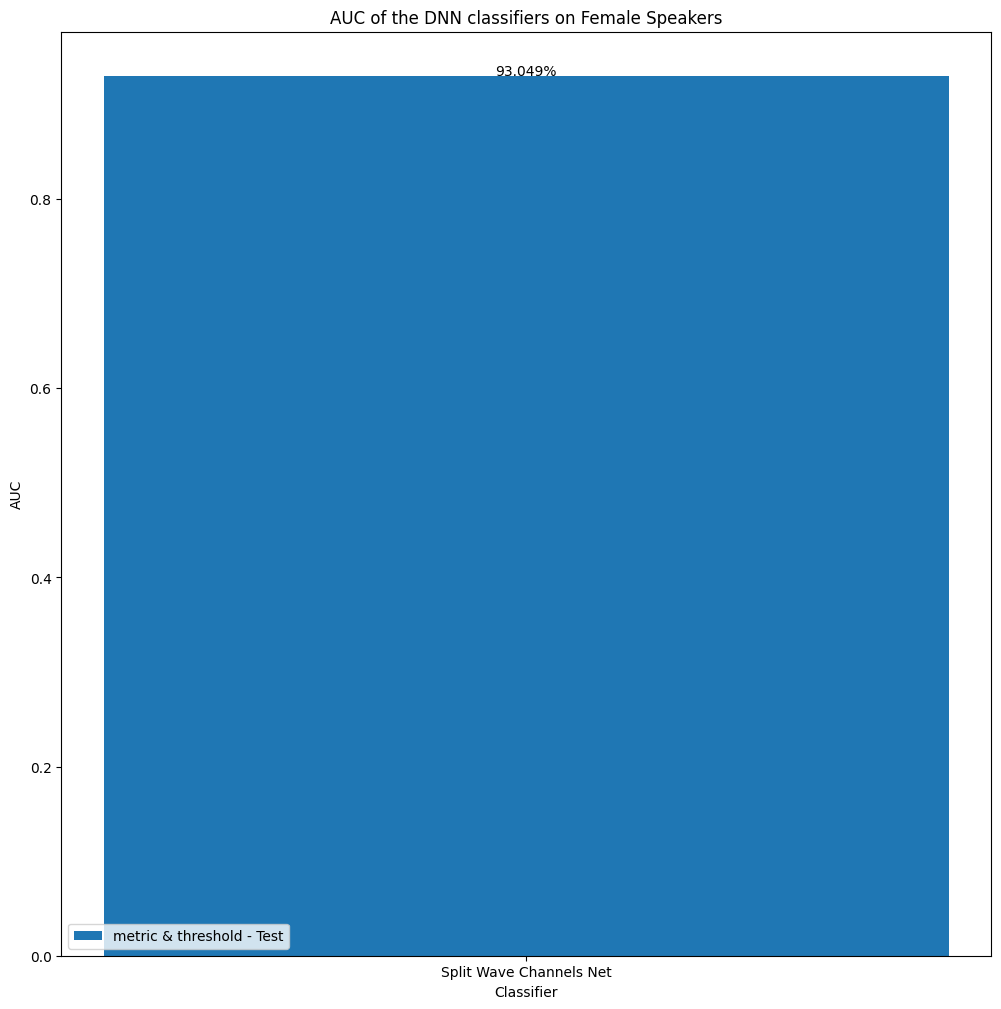

In [26]:
names = ['Split Wave Channels Net']
metric_names = ['EER','Accuracy','Balanced Accuracy','F1','AUC']
#plot hisgogram of the results: EER, Accuracy, Balanced Accuracy, AUC
metrics_list = [eer_list,acc_list,balanced_acc_list,f1_list,auc_list]
validaion_metrics_list = [eer_list_on_validaion,acc_list_with_valid_thr,balanced_acc_list_with_valid_thr,f1_list_with_valid_thr]

diff_for_bar = 0.0001
X_axis = np.arange(len(names))

#Plot the results   
for i in range(0,len(validaion_metrics_list)):
    plt.figure(figsize=(12,12))
    plt.bar(X_axis+0.2, metrics_list[i],width=0.4,label = 'metric & threshold - Test')
    plt.bar(X_axis-0.2, validaion_metrics_list[i],width=0.4,label = 'metric & threshold - validation',color='orange')
    plt.ylabel(metric_names[i])
    plt.xlabel('Classifier')
    plt.title(f"{metric_names[i]} of the classifiers on Female Speakers")
    plt.legend(loc = 'lower left')
    plt.xticks(X_axis, names)
    for j, v in enumerate(metrics_list[i]):
        plt.text(j+0.2, v+diff_for_bar, '{:.3f}%'.format(v*100), ha='center')
    for j, v in enumerate(validaion_metrics_list[i]):
        plt.text(j-0.2, v+diff_for_bar, '{:.3f}%'.format(v*100), ha='center')
    plt.show()
    
plt.figure(figsize=(12,12))
i = len(validaion_metrics_list)   
#plot hisgogram of the results: AUC
plt.figure(figsize=(12,12))
plt.bar(X_axis, metrics_list[i],width=0.4,label = 'metric & threshold - Test')
plt.ylabel(metric_names[i])
plt.xlabel('Classifier')
plt.title(f"{metric_names[i]} of the DNN classifiers on Female Speakers")
plt.legend(loc = 'lower left')
plt.xticks(X_axis, names)
for j, v in enumerate(metrics_list[i]):
        plt.text(j, v+diff_for_bar, '{:.3f}%'.format(v*100), ha='center')   
plt.show()


In [27]:
'''
import pickle

filename = 'female_model_12.00.pkl'
pickle.dump(model, open(filename, 'wb'))
torch.save(model.state_dict(), 'female_model_12000.pth')
'''

"\nimport pickle\n\nfilename = 'female_model_12.00.pkl'\npickle.dump(model, open(filename, 'wb'))\ntorch.save(model.state_dict(), 'female_model_12000.pth')\n"